<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom: 6px;">Day 9 — Notebook 6</h2>


<h3 style="margin-top: 0;">Three-Layer Stacking and Gradient Boosting Concepts</h3>

<p>
This notebook continues after Notebook 5. In Notebook 5, we manually created OOF prediction columns and trained a meta-model.
In this notebook, we extend the same idea into <b>three-layer stacking</b> and then test a compact <b>Gradient Boosting</b> model.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Notebook objective:</b><br>
  Build a clear three-layer stacking workflow, compare it with earlier stacking results, and add a practical Gradient Boosting baseline from the course materials.
</div>

<p>
The code is split into small blocks. Each section explains what we are doing, which variables are used, what new variables are created, and why the step matters.
</p>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Important Points Before Coding</h3>


<table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
  <thead>
    <tr>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Concept</th>
      <th style="text-align: left; border-bottom: 1px solid #888; padding: 6px;">Simple meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;"><b>Level 0</b></td>
      <td style="padding: 6px;">The original base-model prediction columns from Notebook 5.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Level 1</b></td>
      <td style="padding: 6px;">Two models learn from Level 0 predictions and create two new prediction columns.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Level 2</b></td>
      <td style="padding: 6px;">One final model learns from the Level 1 prediction columns and makes the final prediction.</td>
    </tr>
    <tr>
      <td style="padding: 6px;"><b>Gradient Boosting</b></td>
      <td style="padding: 6px;">A sequential ensemble where each new model focuses on correcting previous mistakes.</td>
    </tr>
  </tbody>
</table>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Memory line:</b><br>
  Notebook 5 created prediction columns from base models. Notebook 6 stacks another layer on top of those prediction columns.
</div>


</div>

In [1]:
# Limit heavy parallel processing before importing numerical libraries.
# This helps keep the notebook safe on laptops.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Core data libraries
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# File handling and model saving
from pathlib import Path
import joblib
import gc

# Scikit-learn preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Model selection and cloning
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Models used in this notebook
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">1. Load Data and Notebook 5 Meta-Features</h3>


<p>
We start by loading the same train/test split from Notebook 2.
We also load the <b>OOF meta-feature tables</b> created in Notebook 5.
</p>

<p>
The Notebook 5 meta-feature tables are important because they already contain the base-model prediction columns:
Random Forest probability, Logistic Regression probability, KNN probability, and Decision Tree probability.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Variable flow:</b><br>
  <code>X_train</code> and <code>X_test</code> are used later for Gradient Boosting.<br>
  <code>level0_train_features</code> and <code>level0_test_features</code> are used for three-layer stacking.
</div>


</div>

In [2]:
# Define project folders.
# These are relative paths, so the notebook stays portable.
data_dir = Path("data")
processed_dir = data_dir / "processed"
reports_dir = Path("reports")
models_dir = Path("models")
figures_dir = Path("figures")

# Create output folders if needed.
reports_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# Files created by Notebook 2.
X_train_path = processed_dir / "day9_X_train_raw.csv"
X_test_path = processed_dir / "day9_X_test_raw.csv"
y_train_path = processed_dir / "day9_y_train.csv"
y_test_path = processed_dir / "day9_y_test.csv"

# Files created by Notebook 5.
level0_train_path = reports_dir / "day9_notebook5_oof_meta_train_features.csv"
level0_test_path = reports_dir / "day9_notebook5_oof_meta_test_features.csv"

required_files = [
    X_train_path,
    X_test_path,
    y_train_path,
    y_test_path,
    level0_train_path,
    level0_test_path,
]

missing_files = [str(file_path) for file_path in required_files if not file_path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Notebook 6 needs outputs from Notebook 2 and Notebook 5. "
        f"Missing files: {missing_files}"
    )

# Load original raw train/test data.
# These are mainly needed for the Gradient Boosting section.
X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
y_train = pd.read_csv(y_train_path).squeeze().astype(int)
y_test = pd.read_csv(y_test_path).squeeze().astype(int)

# Load Level 0 meta-features from Notebook 5.
# These are base-model prediction columns, not original customer columns.
level0_train_features = pd.read_csv(level0_train_path)
level0_test_features = pd.read_csv(level0_test_path)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Level 0 train meta-features shape: {level0_train_features.shape}")
print(f"Level 0 test meta-features shape:  {level0_test_features.shape}")

display(level0_train_features.head())

X_train shape: (8929, 16)
X_test shape:  (2233, 16)
Level 0 train meta-features shape: (8929, 4)
Level 0 test meta-features shape:  (2233, 4)


,Random Forest_proba,Logistic Regression_proba,KNN_proba,Decision Tree_proba
0,0.00,0.199156,0.200000,0.0
1,1.00,0.985255,1.000000,1.0
2,0.98,0.686134,0.866667,1.0
3,0.62,0.791250,0.666667,0.0
4,0.70,0.749639,0.466667,1.0


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Loaded Level 0 Features</h3>


<p>
The <b>Level 0 meta-features</b> are the starting point for three-layer stacking.
Each row is one customer, and each column is one base model's probability prediction from Notebook 5.
</p>

<p>
These columns are already prediction-based features. That means the next models will not learn from original customer columns at this stage.
They will learn from model opinions.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>What this step creates:</b><br>
  We now have the Level 0 input tables ready for the three-layer stacking workflow.
</div>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">2. Define Helper Function for Evaluation</h3>


<p>
Before training new models, we create one small helper function to calculate the same metrics every time.
This avoids repeating the same metric code again and again.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Variable flow:</b><br>
  The function receives the real test labels, predicted labels, and predicted probabilities.
  It returns Accuracy, Precision, Recall, F1-score, and ROC-AUC in one dictionary.
</div>


</div>

In [3]:
def evaluate_binary_model(model_name, y_true, y_pred, y_proba):
    """Return the main binary classification metrics in one dictionary."""
    return {
        "Model": model_name,
        "Test_Accuracy": accuracy_score(y_true, y_pred),
        "Test_Precision": precision_score(y_true, y_pred, zero_division=0),
        "Test_Recall": recall_score(y_true, y_pred, zero_division=0),
        "Test_F1": f1_score(y_true, y_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_true, y_proba),
    }

print("Evaluation helper is ready.")

Evaluation helper is ready.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">3. Build Level 1 OOF Predictions</h3>


<p>
Now we build the middle layer of the three-layer stack.
Level 1 uses the Level 0 prediction columns from Notebook 5 as input.
</p>

<p>
We train two Level 1 models:
</p>

<ul>
  <li><b>Level 1 Logistic Regression</b>: simple and stable.</li>
  <li><b>Level 1 Random Forest</b>: more flexible and can capture non-linear patterns between the Level 0 predictions.</li>
</ul>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  Level 0 gave us four base-model opinion columns.
  Level 1 learns from those four opinion columns and creates two new opinion columns.
</div>

<p>
We again use OOF logic. Each Level 1 model trains on 4 folds and predicts the 1 fold it did not see.
This creates fair Level 1 training features for the final Level 2 model.
</p>


</div>

In [4]:
# Create 5-fold split for Level 1 OOF predictions.
# The split is based on the Level 0 training features and the original y_train labels.
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Define the two Level 1 models.
# These models learn from Level 0 prediction columns, not original customer columns.
level1_models = {
    "Level1_LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "Level1_RandomForest": RandomForestClassifier(
        n_estimators=50,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

# Create empty arrays for Level 1 meta-features.
# Rows = customers, columns = Level 1 models.
level1_oof_train = np.zeros((len(level0_train_features), len(level1_models)))

# For the test set, each fold-trained Level 1 model predicts the test Level 0 features.
# Later we average the fold predictions.
level1_test_predictions_by_fold = np.zeros((
    len(level0_test_features),
    len(level1_models),
    cv_strategy.get_n_splits(),
))

# Store fold-level scores for checking the Level 1 models.
level1_fold_score_rows = []

print("Level 1 setup is ready.")
print(f"Level 1 OOF train array shape: {level1_oof_train.shape}")
print(f"Level 1 test prediction array shape: {level1_test_predictions_by_fold.shape}")

Level 1 setup is ready.
Level 1 OOF train array shape: (8929, 2)
Level 1 test prediction array shape: (2233, 2, 5)


In [5]:
# Loop through folds to create fair Level 1 OOF predictions.
for fold_number, (fold_train_index, fold_valid_index) in enumerate(
    cv_strategy.split(level0_train_features, y_train),
    start=1,
):
    print(f"Starting Level 1 fold {fold_number}")

    # Split Level 0 features into fold-training and fold-validation parts.
    # The validation fold is hidden from the Level 1 model during training.
    X_level1_fold_train = level0_train_features.iloc[fold_train_index]
    y_level1_fold_train = y_train.iloc[fold_train_index]
    X_level1_fold_valid = level0_train_features.iloc[fold_valid_index]
    y_level1_fold_valid = y_train.iloc[fold_valid_index]

    # Train each Level 1 model and store its fair validation predictions.
    for model_position, (model_name, model) in enumerate(level1_models.items()):
        print(f"  Training {model_name}")

        # Clone gives a clean model for this fold.
        level1_fold_model = clone(model)
        level1_fold_model.fit(X_level1_fold_train, y_level1_fold_train)

        # Predict the hidden validation fold.
        valid_probability = level1_fold_model.predict_proba(X_level1_fold_valid)[:, 1]
        valid_prediction = (valid_probability >= 0.5).astype(int)

        # Store fair OOF predictions in the correct rows and model column.
        level1_oof_train[fold_valid_index, model_position] = valid_probability

        # Predict the Level 0 test features with this fold-trained Level 1 model.
        test_probability = level1_fold_model.predict_proba(level0_test_features)[:, 1]
        level1_test_predictions_by_fold[:, model_position, fold_number - 1] = test_probability

        # Save validation quality checks for this fold and model.
        level1_fold_score_rows.append({
            "Fold": fold_number,
            "Level1_Model": model_name,
            "Validation_F1": f1_score(y_level1_fold_valid, valid_prediction, zero_division=0),
            "Validation_ROC_AUC": roc_auc_score(y_level1_fold_valid, valid_probability),
        })

        # Free fold model memory.
        del level1_fold_model
        gc.collect()

    # Free temporary fold variables.
    del X_level1_fold_train, y_level1_fold_train, X_level1_fold_valid, y_level1_fold_valid
    gc.collect()

print("Level 1 OOF predictions created successfully.")

Starting Level 1 fold 1
  Training Level1_LogisticRegression
  Training Level1_RandomForest
Starting Level 1 fold 2
  Training Level1_LogisticRegression
  Training Level1_RandomForest
Starting Level 1 fold 3
  Training Level1_LogisticRegression
  Training Level1_RandomForest
Starting Level 1 fold 4
  Training Level1_LogisticRegression
  Training Level1_RandomForest
Starting Level 1 fold 5
  Training Level1_LogisticRegression
  Training Level1_RandomForest
Level 1 OOF predictions created successfully.


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">4. Inspect Level 1 Meta-Features</h3>


<p>
Now we inspect the Level 1 prediction table.
This table has two columns because we trained two Level 1 models.
</p>

<p>
Each row is still one training customer.
Each column is a fair OOF prediction from one Level 1 model.
These two columns will become the input for the final Level 2 model.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Variable flow:</b><br>
  <code>level0_train_features</code> had 4 columns from the original base models.<br>
  <code>level1_meta_train</code> will have 2 columns from the Level 1 models.<br>
  The final Level 2 model learns from these 2 columns.
</div>


</div>

In [6]:
# Create readable column names for the Level 1 prediction columns.
level1_feature_names = [
    "Level1_LogisticRegression_proba",
    "Level1_RandomForest_proba",
]

# Convert Level 1 OOF predictions into a DataFrame.
level1_meta_train = pd.DataFrame(
    level1_oof_train,
    columns=level1_feature_names,
)

# Average Level 1 test predictions across the five fold-trained models.
level1_meta_test = pd.DataFrame(
    level1_test_predictions_by_fold.mean(axis=2),
    columns=level1_feature_names,
)

# Summarize Level 1 fold performance.
level1_fold_scores = pd.DataFrame(level1_fold_score_rows)
level1_fold_summary = (
    level1_fold_scores
    .groupby("Level1_Model", as_index=False)
    .agg(
        Mean_Validation_F1=("Validation_F1", "mean"),
        Std_Validation_F1=("Validation_F1", "std"),
        Mean_Validation_ROC_AUC=("Validation_ROC_AUC", "mean"),
        Std_Validation_ROC_AUC=("Validation_ROC_AUC", "std"),
    )
    .sort_values("Mean_Validation_F1", ascending=False)
)

level1_fold_summary_rounded = level1_fold_summary.copy()
metric_columns = [col for col in level1_fold_summary_rounded.columns if col != "Level1_Model"]
level1_fold_summary_rounded[metric_columns] = level1_fold_summary_rounded[metric_columns].round(4)

print(f"Level 1 train meta-feature shape: {level1_meta_train.shape}")
print(f"Level 1 test meta-feature shape:  {level1_meta_test.shape}")

display(level1_meta_train.head())
display(level1_fold_summary_rounded)

Level 1 train meta-feature shape: (8929, 2)
Level 1 test meta-feature shape:  (2233, 2)


,Level1_LogisticRegression_proba,Level1_RandomForest_proba
0,0.051512,0.02
1,0.964300,0.76
2,0.937068,0.80
3,0.712553,0.76
4,0.764263,0.92


,Level1_Model,Mean_Validation_F1,Std_Validation_F1,Mean_Validation_ROC_AUC,Std_Validation_ROC_AUC
0,Level1_LogisticRegression,0.8487,0.0071,0.9216,0.0045
1,Level1_RandomForest,0.8203,0.0079,0.8919,0.0028


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Level-1 Model Comparison</h3>

<p>
This table compares the two <b>Level-1 models</b> used in the three-layer stacking setup:
<b>Logistic Regression</b> and <b>Random Forest</b>.
</p>

<p>
The Level-1 models do not learn directly from the original customer columns.
They learn from the Level-0 base-model prediction columns created earlier.
Their job is to create stronger intermediate predictions for the final Level-2 model.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best Level-1 model:</b><br>
  <b>Level1_LogisticRegression</b> performed better, with a mean validation F1-score of
  <b>0.8487</b> and mean validation ROC-AUC of <b>0.9216</b>.
</div>

<p>
The <b>Level1_RandomForest</b> model performed weaker in this setup.
It achieved a mean validation F1-score of <b>0.8203</b> and mean validation ROC-AUC of <b>0.8919</b>.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple explanation:</b><br>
  At Level 1, the input data is already prediction-based.
  A simple Logistic Regression model can combine these prediction columns very effectively.
  A more complex Random Forest model does not automatically perform better here.
</div>

<p>
The standard deviation values are small for both models.
This means the validation results are reasonably stable across folds.
However, Logistic Regression is clearly stronger because it has both higher F1-score and higher ROC-AUC.
</p>

<p>
For the next step, these Level-1 prediction outputs will be passed into the final <b>Level-2 model</b>.
The final model will learn from the Level-1 outputs and produce the final three-layer stacking prediction.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">5. Train the Final Level-2 Model</h3>

<p>
Now we train the final model in the three-layer stacking system.
This final model is called the <b>Level-2 model</b>.
Its job is to make the final prediction using the outputs from Level 1.
</p>

<p>
The Level-2 model does <b>not</b> use the original customer columns such as age, balance, job, campaign, or duration.
It also does <b>not</b> directly use the four Level-0 base-model prediction columns.
Instead, it learns from the two prediction columns created by the Level-1 models.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  Level 0 creates the first model opinions.
  Level 1 combines those opinions into two stronger prediction columns.
  Level 2 combines the two Level-1 prediction columns into the final prediction.
</div>

<p>
So the variable flow is:
</p>

<ul>
  <li><b>Level 0:</b> base models create prediction probabilities.</li>
  <li><b>Level 1:</b> two models learn from those Level-0 prediction probabilities.</li>
  <li><b>Level 2:</b> the final model learns from the two Level-1 prediction probabilities.</li>
</ul>

<p>
We use <b>Logistic Regression</b> as the Level-2 model because it is simple, stable, and easy to explain.
At this stage, the input already contains prediction-based information, so a simple final model is usually enough.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>What this step creates:</b><br>
  A final trained Level-2 model that can take the two Level-1 prediction columns
  and produce the final three-layer stacking prediction.
</div>

</div>

In [7]:
# Define the final Level 2 model.
# It learns from the two Level 1 prediction columns.
level2_final_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)

# Train Level 2 on the Level 1 OOF meta-features.
level2_final_model.fit(level1_meta_train, y_train)

# Predict on the Level 1 test meta-features.
three_layer_pred = level2_final_model.predict(level1_meta_test)
three_layer_proba = level2_final_model.predict_proba(level1_meta_test)[:, 1]

# Evaluate the full three-layer stack on the held-out test set.
three_layer_result = evaluate_binary_model(
    model_name="Three-Layer Stacking",
    y_true=y_test,
    y_pred=three_layer_pred,
    y_proba=three_layer_proba,
)

three_layer_result_rounded = pd.DataFrame([three_layer_result]).round(4)
display(three_layer_result_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Three-Layer Stacking,0.8612,0.8369,0.8781,0.857,0.9251


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Three-Layer Stacking Result</h3>

<p>
The <b>Three-Layer Stacking</b> model has now been evaluated on the held-out test set.
This model uses multiple stacking levels instead of only one meta-model.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  Three-Layer Stacking achieved a <b>test F1-score of 0.8570</b>
  and a <b>test ROC-AUC of 0.9251</b>.
</div>

<p>
The test accuracy is <b>0.8612</b>, meaning the model correctly classified about
<b>86.12%</b> of the test customers.
</p>

<p>
The precision is <b>0.8369</b>, meaning that when the model predicted a customer would subscribe,
about <b>83.69%</b> of those predictions were correct.
</p>

<p>
The recall is <b>0.8781</b>, meaning the model caught about <b>87.81%</b> of the actual subscribers.
This is useful for the marketing use case because it helps identify more likely subscribers.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple interpretation:</b><br>
  Three-Layer Stacking performs strongly, but the improvement over Manual OOF Stacking is very small.
  This means the extra stacking layer works, but it may not add enough business value to justify the extra complexity.
</div>

<p>
This result should be compared against Notebook 5 Manual OOF Stacking.
If the performance gain is only marginal, the simpler OOF stacking model may be easier to explain, maintain, and use in a real business setting.
</p>

</div>

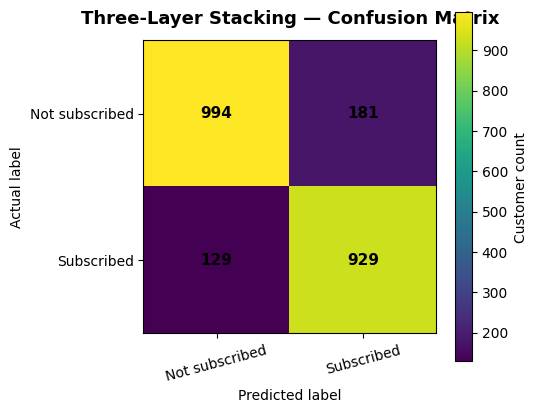

In [8]:
# Create a confusion matrix for the three-layer stack.
three_layer_cm = confusion_matrix(y_test, three_layer_pred)

plt.figure(figsize=(5.4, 4.6))
plt.imshow(three_layer_cm)
plt.title("Three-Layer Stacking — Confusion Matrix", fontsize=13, weight="bold", pad=12)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.xticks([0, 1], ["Not subscribed", "Subscribed"], rotation=15)
plt.yticks([0, 1], ["Not subscribed", "Subscribed"])
plt.colorbar(label="Customer count")

# Add numbers inside each cell.
for row in range(three_layer_cm.shape[0]):
    for col in range(three_layer_cm.shape[1]):
        plt.text(
            col,
            row,
            str(three_layer_cm[row, col]),
            ha="center",
            va="center",
            fontsize=11,
            weight="bold",
        )

plt.tight_layout()
plt.savefig(figures_dir / "day9_notebook6_three_layer_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Three-Layer Stacking Confusion Matrix</h3>

<p>
This confusion matrix shows how the <b>Three-Layer Stacking</b> model predicted the held-out test customers.
</p>

<ul>
  <li><b>994</b> not-subscribed customers were correctly predicted as not subscribed.</li>
  <li><b>929</b> subscribed customers were correctly predicted as subscribed.</li>
  <li><b>181</b> not-subscribed customers were incorrectly predicted as subscribed.</li>
  <li><b>129</b> subscribed customers were incorrectly predicted as not subscribed.</li>
</ul>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  The model correctly identified <b>929 actual subscribers</b> and missed only <b>129 subscribers</b>.
</div>

<p>
For a marketing campaign, the most important number is often the missed subscribers.
Here, the model missed <b>129</b> actual subscribers.
This is acceptable because the model still catches a large share of real subscribers.
</p>

<p>
The model also created <b>181 false positives</b>.
These are customers predicted as subscribers but actually not subscribed.
In business terms, this means some campaign effort may be spent on customers who are less likely to convert.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple interpretation:</b><br>
  Three-Layer Stacking catches most subscribers while keeping false positives reasonably controlled.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">6. Build a Compact Gradient Boosting Model</h3>


<p>
The uploaded course materials also include <b>Boosting</b> and <b>Gradient Boosting</b>.
So we add a compact practical Gradient Boosting model for comparison.
</p>

<p>
Gradient Boosting is different from Random Forest and stacking.
Random Forest trains many trees in parallel-style independence, while Gradient Boosting trains models sequentially.
Each new tree tries to correct the mistakes left by the earlier trees.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  Random Forest says: many trees vote together.<br>
  Stacking says: several models give opinions and a meta-model combines them.<br>
  Gradient Boosting says: learn step by step, correcting previous mistakes.
</div>

<p>
This section is a practical concept check, not a full Gradient Boosting tuning project.
We keep the settings moderate so the notebook remains safe to run.
</p>


</div>

In [9]:
# Rebuild preprocessing for Gradient Boosting.
# This uses the original customer columns from X_train and X_test.
numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Compatibility for older scikit-learn versions.
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", categorical_encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ],
    remainder="drop",
)

print(f"Numeric columns: {len(numeric_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

Numeric columns: 7
Categorical columns: 9


In [ ]:
# Define a compact Gradient Boosting pipeline.
# n_estimators is kept moderate so the notebook stays safe to run.

gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=80,
        learning_rate=0.06,
        max_depth=3,
        random_state=RANDOM_STATE,
    )),
])

# Train on the original training data.
gradient_boosting_pipeline.fit(X_train, y_train)

# Predict on the held-out test set.
gb_pred = gradient_boosting_pipeline.predict(X_test)
gb_proba = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

# Evaluate Gradient Boosting.
gradient_boosting_result = evaluate_binary_model(
    model_name="Gradient Boosting",
    y_true=y_test,
    y_pred=gb_pred,
    y_proba=gb_proba,
)

gradient_boosting_result_rounded = pd.DataFrame([gradient_boosting_result]).round(4)
display(gradient_boosting_result_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Gradient Boosting,0.8325,0.8109,0.8431,0.8267,0.9123


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Gradient Boosting Result</h3>


<p>
This output shows how a compact Gradient Boosting model performs on the same held-out test set.
Unlike three-layer stacking, this model learns directly from the original customer columns after preprocessing.
</p>

<p>
Gradient Boosting is useful because it often performs strongly on tabular business data.
However, it can require careful tuning of learning rate, number of trees, tree depth, and regularization.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point:</b><br>
  This is a controlled Gradient Boosting check, not a complete boosting tuning exercise.
  The goal is to connect the course concept to practice and compare it with our stacking results.
</div>


</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">7. Compare Notebook 6 Models with Earlier Results</h3>


<p>
Now we compare the Notebook 6 models with the best saved results from earlier notebooks.
This helps us answer the main expert-level question: does the extra stacking complexity give enough value?
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Decision logic:</b><br>
  If three-layer stacking only gives a tiny improvement, it may not be worth the extra complexity.
  A simpler model can be better for explanation, maintenance, and business use.
</div>


</div>

In [11]:
# Build comparison table starting with Notebook 6 results.
comparison_rows = []
comparison_rows.append(three_layer_result)
comparison_rows.append(gradient_boosting_result)

# Add Notebook 5 manual OOF/blending comparison if the file exists.
notebook5_comparison_path = reports_dir / "day9_notebook5_oof_vs_blending_comparison.csv"
if notebook5_comparison_path.exists():
    notebook5_comparison = pd.read_csv(notebook5_comparison_path)
    for _, row in notebook5_comparison.iterrows():
        comparison_rows.append({
            "Model": row["Model"],
            "Test_Accuracy": row["Test_Accuracy"],
            "Test_Precision": row["Test_Precision"],
            "Test_Recall": row["Test_Recall"],
            "Test_F1": row["Test_F1"],
            "Test_ROC_AUC": row["Test_ROC_AUC"],
        })

# Add Notebook 4 stacking comparison if the file exists.
notebook4_test_path = reports_dir / "day9_notebook4_test_stacking_results.csv"
if notebook4_test_path.exists():
    notebook4_test_results = pd.read_csv(notebook4_test_path)
    for _, row in notebook4_test_results.iterrows():
        comparison_rows.append({
            "Model": row["Model"],
            "Test_Accuracy": row["Test_Accuracy"],
            "Test_Precision": row["Test_Precision"],
            "Test_Recall": row["Test_Recall"],
            "Test_F1": row["Test_F1"],
            "Test_ROC_AUC": row["Test_ROC_AUC"],
        })

# Create final comparison table.
notebook6_comparison = (
    pd.DataFrame(comparison_rows)
    .drop_duplicates(subset=["Model"], keep="first")
    .sort_values("Test_F1", ascending=False)
    .reset_index(drop=True)
)

notebook6_comparison_rounded = notebook6_comparison.copy()
metric_columns = [col for col in notebook6_comparison_rounded.columns if col != "Model"]
notebook6_comparison_rounded[metric_columns] = notebook6_comparison_rounded[metric_columns].round(4)

display(notebook6_comparison_rounded)

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,StackingClassifier (RF meta),0.8598,0.8176,0.9064,0.8597,0.9247
1,Three-Layer Stacking,0.8612,0.8369,0.8781,0.8570,0.9251
2,Manual OOF Stacking,0.8603,0.8354,0.8781,0.8562,0.9259
3,StackingClassifier (LR meta),0.8589,0.8338,0.8771,0.8549,0.9265
4,Blending 70/30,0.8554,0.8314,0.8715,0.8509,0.9232
5,Gradient Boosting,0.8325,0.8109,0.8431,0.8267,0.9123


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Final Model Comparison</h3>

<p>
This table compares all major ensemble models tested so far.
The goal is not only to find the highest number, but also to decide which model gives the best balance between
performance, complexity, and business usefulness.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best F1-score:</b><br>
  <b>StackingClassifier with Random Forest meta-model</b> has the best test F1-score:
  <b>0.8597</b>.
</div>

<p>
The <b>Three-Layer Stacking</b> model achieved the highest test accuracy:
<b>0.8612</b>. 
It also has strong precision and ROC-AUC, but its F1-score is slightly lower than the RF-meta StackingClassifier.
</p>

<p>
The <b>Manual OOF Stacking</b> model is also very strong.
It achieved a test F1-score of <b>0.8562</b> and the second-best ROC-AUC of <b>0.9259</b>.
This confirms that our manual OOF stacking process worked correctly.
</p>

<p>
The <b>StackingClassifier with Logistic Regression meta-model</b> achieved the best ROC-AUC:
<b>0.9265</b>.
This means it is very good at ranking likely subscribers versus non-subscribers.
However, its F1-score is slightly lower than the RF-meta stacking model.
</p>

<p>
The <b>Blending 70/30</b> model performed well, but it was weaker than OOF stacking.
This matches the theory: blending is simpler and faster, but it depends more on one train/blend split.
</p>

<p>
The <b>Gradient Boosting</b> model performed the weakest in this comparison.
It still produced reasonable results, but it did not beat the stacking-based models on this dataset.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Business decision:</b><br>
  If the goal is the best balanced subscriber prediction, choose
  <b>StackingClassifier with Random Forest meta-model</b>.
  It gives the strongest F1-score and the highest recall.
</div>

<p>
Three-Layer Stacking works, but the improvement is not large enough to clearly justify the extra complexity.
For a real business project, the RF-meta stacking model is easier to justify because it gives the best F1-score
without adding another stacking layer.
</p>

</div>

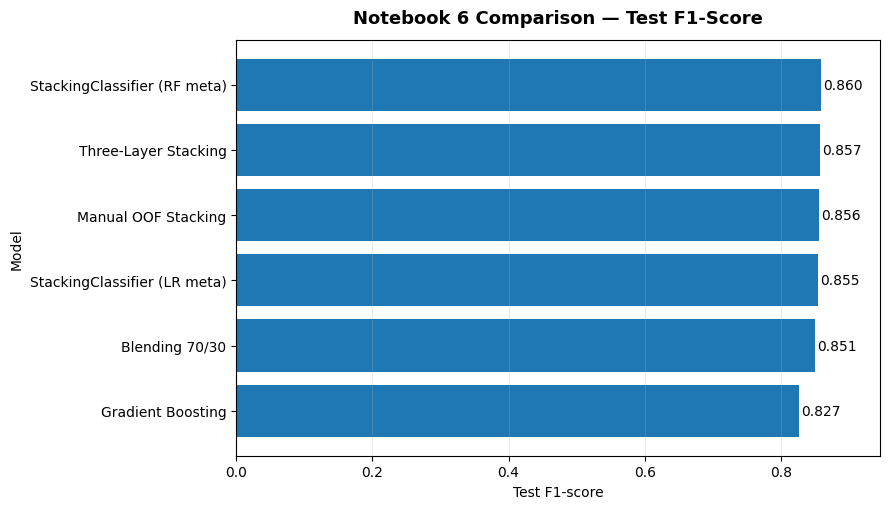

In [12]:
# Plot model comparison by Test F1-score.
plot_data = notebook6_comparison.sort_values("Test_F1", ascending=True)

plt.figure(figsize=(9, 5.2))
bars = plt.barh(plot_data["Model"], plot_data["Test_F1"])

plt.title("Notebook 6 Comparison — Test F1-Score", fontsize=13, weight="bold", pad=12)
plt.xlabel("Test F1-score")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.25)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

plt.xlim(0, max(plot_data["Test_F1"]) * 1.10)
plt.tight_layout()
plt.savefig(figures_dir / "day9_notebook6_model_comparison_f1.png", dpi=160, bbox_inches="tight")
plt.show()

<<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Output Interpretation: Complexity vs Value</h3>

<p>
This table is the main decision point for Notebook 6.
It compares the three-layer stacking model with the simpler stacking methods from Notebook 4 and Notebook 5.
</p>

<p>
The question is simple:
<b>Does the extra stacking layer give enough improvement to justify the extra complexity?</b>
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Simple idea:</b><br>
  A complex model is not automatically better.
  It is only better if it gives a meaningful improvement or solves a real business problem.
</div>

<p>
Three-Layer Stacking performs strongly.
It achieved the highest test accuracy at <b>0.8612</b> and a strong F1-score of <b>0.8570</b>.
However, the best F1-score still belongs to the simpler <b>StackingClassifier with Random Forest meta-model</b>,
with a test F1-score of <b>0.8597</b>.
</p>

<p>
Manual OOF Stacking is also very close, with a test F1-score of <b>0.8562</b> and ROC-AUC of <b>0.9259</b>.
This means the simpler stacking methods already perform almost as well as the three-layer model.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Business rule:</b><br>
  Do not choose a more complex model only because it looks advanced.
  Choose it only if the performance gain is clearly worth the extra maintenance, explanation, and production effort.
</div>

<p>
For this project, the three-layer stack does <b>not</b> provide a large enough improvement.
The simpler RF-meta StackingClassifier remains the better practical recommendation because it gives the best F1-score
and is easier to explain and maintain.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">8. Save Notebook 6 Outputs</h3>


<p>
We save the key Notebook 6 outputs so the final MVD proof notebook and project documentation can reuse them.
</p>


</div>

In [13]:
# Save Level 1 fold summary and model results.
level1_fold_summary_rounded.to_csv(
    reports_dir / "day9_notebook6_level1_fold_summary.csv",
    index=False,
)

three_layer_result_rounded.to_csv(
    reports_dir / "day9_notebook6_three_layer_stacking_result.csv",
    index=False,
)

gradient_boosting_result_rounded.to_csv(
    reports_dir / "day9_notebook6_gradient_boosting_result.csv",
    index=False,
)

notebook6_comparison_rounded.to_csv(
    reports_dir / "day9_notebook6_model_comparison.csv",
    index=False,
)

# Save Level 1 and Level 2 meta-feature tables for transparency.
level1_meta_train.to_csv(
    reports_dir / "day9_notebook6_level1_meta_train_features.csv",
    index=False,
)

level1_meta_test.to_csv(
    reports_dir / "day9_notebook6_level1_meta_test_features.csv",
    index=False,
)

# Train final Level 1 models on all Level 0 training features for reference saving.
# These are useful for documentation, but the evaluation above used OOF logic.
final_level1_models = {}
for model_name, model in level1_models.items():
    final_model = clone(model)
    final_model.fit(level0_train_features, y_train)
    final_level1_models[model_name] = final_model

# Save trained models.
joblib.dump(
    final_level1_models,
    models_dir / "day9_notebook6_final_level1_models.joblib",
)

joblib.dump(
    level2_final_model,
    models_dir / "day9_notebook6_level2_final_model.joblib",
)

joblib.dump(
    gradient_boosting_pipeline,
    models_dir / "day9_notebook6_gradient_boosting_pipeline.joblib",
)

# Save short notebook summary.
best_model_row = notebook6_comparison.iloc[0]
three_layer_rank = int(
    notebook6_comparison.index[notebook6_comparison["Model"] == "Three-Layer Stacking"][0] + 1
)

notebook6_summary = pd.DataFrame([{
    "Best_Model_In_Comparison": best_model_row["Model"],
    "Best_Test_F1": best_model_row["Test_F1"],
    "Best_Test_ROC_AUC": best_model_row["Test_ROC_AUC"],
    "Three_Layer_Stacking_Test_F1": three_layer_result["Test_F1"],
    "Three_Layer_Stacking_Rank_By_F1": three_layer_rank,
    "Gradient_Boosting_Test_F1": gradient_boosting_result["Test_F1"],
}])

notebook6_summary_rounded = notebook6_summary.round(4)
notebook6_summary_rounded.to_csv(
    reports_dir / "day9_notebook6_summary.csv",
    index=False,
)

print("Notebook 6 outputs saved successfully.")
print(f"Reports saved in: {reports_dir}")
print(f"Models saved in: {models_dir}")
print(f"Figures saved in: {figures_dir}")

display(notebook6_summary_rounded)

Notebook 6 outputs saved successfully.
Reports saved in: reports
Models saved in: models
Figures saved in: figures


,Best_Model_In_Comparison,Best_Test_F1,Best_Test_ROC_AUC,Three_Layer_Stacking_Test_F1,Three_Layer_Stacking_Rank_By_F1,Gradient_Boosting_Test_F1
0,StackingClassifier (RF meta),0.8597,0.9247,0.857,2,0.8267


<<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Notebook 6</h3>

<p>
In this notebook, we extended the stacking workflow into a <b>three-layer stacking</b> structure.
The goal was to check whether adding extra stacking layers gives a meaningful improvement over the simpler stacking methods from Notebook 4 and Notebook 5.
</p>

<p>
The three-layer structure worked like this:
</p>

<ul>
  <li><b>Level 0:</b> base models created prediction probabilities.</li>
  <li><b>Level 1:</b> two intermediate models learned from the Level-0 prediction probabilities.</li>
  <li><b>Level 2:</b> the final model learned from the two Level-1 prediction columns and produced the final prediction.</li>
</ul>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Three-layer stacking result:</b><br>
  The model achieved <b>0.8612 test accuracy</b>, <b>0.8570 test F1-score</b>,
  and <b>0.9251 test ROC-AUC</b>.
</div>

<p>
This is a strong result. However, the three-layer model did <b>not</b> clearly beat the simpler stacking approaches.
The best F1-score still came from the <b>StackingClassifier with Random Forest meta-model</b>,
with a test F1-score of <b>0.8597</b>.
</p>

<p>
This means the three-layer stack works technically, but the extra complexity does not give enough performance gain
to make it the best practical recommendation.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main learning:</b><br>
  More model layers do not automatically mean a better model.
  A model should be chosen based on performance, explainability, stability, and business value.
</div>

<p>
We also trained a compact <b>Gradient Boosting</b> model to connect the course boosting theory with practice.
Gradient Boosting learns sequentially: each new tree tries to correct mistakes from the previous trees.
In this project, Gradient Boosting performed reasonably, but it was weaker than the stacking-based methods.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Final business recommendation from Notebook 6:</b><br>
  Prefer the simpler <b>StackingClassifier with Random Forest meta-model</b>.
  It gives the best F1-score and is easier to explain and maintain than the three-layer stack.
</div>

<p>
The next notebook will create the final <b>MVD proof checklist</b>, consolidate all results,
and prepare the final business recommendation for the Learning Day 9 project.
</p>

</div>